In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

# ----- helpers -----
def _next_data_line(lines, i):
    """Return index of next non-empty, non-comment line."""
    n = len(lines)
    while i < n:
        s = lines[i].strip()
        if s and not s.startswith("#"):
            return i
        i += 1
    return i

def parse_mfem_mesh(path):
    """
    Parse MFEM ASCII mesh v1.0 and return (dim, vertices[N, dim]).
    Robust to line breaks in vertex coordinates.
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    i = 0
    # find 'dimension'
    while i < len(lines) and "dimension" not in lines[i].lower():
        i += 1
    if i == len(lines):
        raise ValueError("Could not find 'dimension' in mesh file.")
    i = _next_data_line(lines, i+1)
    dim = int(float(lines[i].strip())); i += 1

    # find 'vertices'
    while i < len(lines) and "vertices" not in lines[i].lower():
        i += 1
    if i == len(lines):
        raise ValueError("Could not find 'vertices' in mesh file.")
    i = _next_data_line(lines, i+1)
    nv = int(float(lines[i].strip())); i += 1

    # some files include a vdim line; if not, assume vdim == dim
    i = _next_data_line(lines, i)
    vdim = None
    try:
        possible = int(float(lines[i].strip().split()[0]))
        if 1 <= possible <= 3:
            vdim = possible
            i += 1
    except Exception:
        pass
    if vdim is None:
        vdim = dim

    # read nv vertices with vdim coords (allow coordinates to span lines)
    verts, acc, read_count = [], [], 0
    while read_count < nv:
        s = lines[i].strip(); i += 1
        if not s or s.startswith("#"):
            continue
        for t in s.split():
            try:
                acc.append(float(t))
            except Exception:
                pass
        while len(acc) >= vdim and read_count < nv:
            verts.append(acc[:vdim])
            acc = acc[vdim:]
            read_count += 1

    V = np.array(verts, dtype=float)
    if V.shape != (nv, vdim):
        raise ValueError(f"Vertex array has wrong shape {V.shape}, expected ({nv},{vdim})")
    return dim, V

def parse_mfem_gridfunction(path):
    """
    Parse MFEM ASCII scalar GridFunction to a 1D numpy array.
    (Assumes header lines with 'FiniteElementSpace', 'Ordering', etc.)
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    # find "Ordering" then next blank line; data follows
    i = 0
    while i < len(lines):
        if lines[i].strip().lower().startswith("ordering"):
            i += 1
            while i < len(lines) and lines[i].strip() != "":
                i += 1
            break
        i += 1
    data = []
    for j in range(i, len(lines)):
        s = lines[j].strip()
        if not s or s.startswith("#") or s == "...":
            continue
        for token in s.split():
            try:
                data.append(float(token))
            except ValueError:
                pass
    return np.array(data, dtype=float)


In [2]:
# Update these paths if your files are elsewhere
# mesh_path = "inputs/pmesh.000000"
# field_path = "inputs/CnCH.000000"

mesh_path = "outputs/Results/20250820_092154__nsteps=3__mesh=Mesh_3x90_r/pmesh.000000"
field_path = "outputs/Results/20250820_092154__nsteps=3__mesh=Mesh_3x90_r/pCnCH.000000"


In [3]:
dim, V = parse_mfem_mesh(mesh_path)
vals = parse_mfem_gridfunction(field_path)

nv = V.shape[0]
if vals.size < nv:
    raise ValueError(f"GridFunction has {vals.size} values, mesh has {nv} vertices.")
nodal_vals = vals[:nv]          # assumes H1 P1 nodal ordering

print(f"mesh dimension: {dim}")
print(f"num vertices:   {nv}")
print(f"value range:    {nodal_vals.min():.6g} .. {nodal_vals.max():.6g}")
print(f"mean:           {nodal_vals.mean():.6g}")


mesh dimension: 2
num vertices:   364
value range:    2.02e-08 .. 0.0202001
mean:           0.00677112


In [9]:
if dim == 3:
    z = V[:,2]
    zmid = float(np.median(z))
    tol = 0.05 * (z.max() - z.min() if z.max() > z.min() else 1.0)  # 5% thickness
    mask = np.abs(z - zmid) <= tol

    if np.count_nonzero(mask) > 50:
        fig2 = plt.figure(figsize=(6,6))
        ax2 = fig2.add_subplot(111)
        sc2 = ax2.scatter(V[mask,0], V[mask,1], c=nodal_vals[mask], s=6)
        ax2.set_aspect('equal', adjustable='box')
        ax2.set_title(f"mid slice")
        ax2.set_xlabel("x"); ax2.set_ylabel("y")
        plt.colorbar(sc2, ax=ax2)
        plt.show()
    else:
        print("Not enough points near median z for a mid-Z slice.")



In [6]:
if dim == 3:
    z = V[:, 2]
    zmax = float(z.max())

    # Pick a thin layer near the top: either 5% of z-range OR one z-layer if the mesh is layered.
    # Method A (simple): fixed thickness as a fraction of the z-range
    tol = 0.05 * (z.max() - z.min() if z.max() > z.min() else 1.0)

    # Optional Method B (layer-aware): use ~1.5× the smallest z-spacing seen
    # uniq = np.unique(np.round(z, 12))           # round to merge tiny fp jitter
    # dz = np.diff(np.sort(uniq))
    # if dz.size > 0:
    #     tol = max(tol, 1.5 * dz.min())

    mask = (z >= zmax - tol)

    if np.count_nonzero(mask) > 50:
        fig2 = plt.figure(figsize=(6, 6))
        ax2 = fig2.add_subplot(111)
        sc2 = ax2.scatter(V[mask, 0], V[mask, 1], c=nodal_vals[mask], s=6)
        ax2.set_aspect('equal', adjustable='box')
        ax2.set_title("Top slice (z ≈ z_max)")
        ax2.set_xlabel("x"); ax2.set_ylabel("y")
        plt.colorbar(sc2, ax=ax2)
        plt.show()
    else:
        print("Not enough points near the top surface for a slice.")


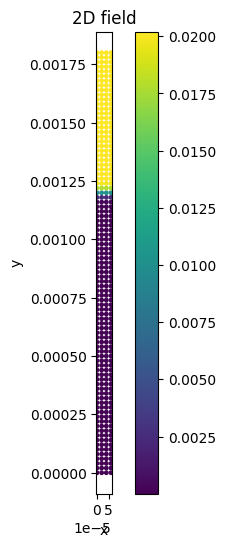

In [17]:
if dim == 2:
    # V: (N,2) array of node coords, nodal_vals: (N,) values at nodes
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)

    sc = ax.scatter(V[:, 0], V[:, 1], c=nodal_vals, s=6)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title("2D field")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(sc, ax=ax)
    plt.show()






